# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

Data Description
-
The data is stored in the imdb_reviews.tsv file. Download the dataset.

The data was provided by Andrew L. Maas, Raymond E. Daly, Peter T. Pham, Dan Huang, Andrew Y. Ng, and Christopher Potts. (2011). Learning Word Vectors for Sentiment Analysis. The 49th Annual Meeting of the Association for Computational Linguistics (ACL 2011).

Here's the description of the selected fields:

- review: the review text
- pos: the target, '0' for negative and '1' for positive
- ds_part: 'train'/'test' for the train/test part of dataset, correspondingly
There are other fields in the dataset. Feel free to explore them if you'd like.

## Initialization

In [51]:
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.auto import tqdm
import sklearn.metrics as metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from lightgbm import LGBMClassifier
from tqdm import tqdm, tqdm_notebook
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import gc
import re
import math
import spacy
import torch
import transformers

import warnings
warnings.filterwarnings("ignore")

In [52]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [53]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [54]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [55]:
df_reviews.head(10)

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281
5,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,This is the first movie I've seen from Singapo...,9,pos,1,test,9282
6,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Yes non-Singaporean's can't see what's the big...,9,pos,1,test,9283
7,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,This true story of Carlson's Raiders is more o...,2,neg,0,train,9903
8,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,Should have been titled 'Balderdash!' Little i...,2,neg,0,train,9905
9,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,The movie 'Gung Ho!': The Story of Carlson's M...,4,neg,0,train,9904


In [56]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [57]:
# Check for missing values
df_reviews.isnull().sum()

tconst             0
title_type         0
primary_title      0
original_title     0
start_year         0
end_year           0
runtime_minutes    0
is_adult           0
genres             0
average_rating     2
votes              2
review             0
rating             0
sp                 0
pos                0
ds_part            0
idx                0
dtype: int64

In [58]:
df_reviews[df_reviews["average_rating"].isna()]

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
22280,tt0192317,movie,Mila Ass Painting,Mila Ass Painting,1998,\N,\N,0,\N,NaN,<NA>,"This is a truly great film, with excellent dir...",9,pos,1,test,3231
22281,tt0192317,movie,Mila Ass Painting,Mila Ass Painting,1998,\N,\N,0,\N,NaN,<NA>,"A film is beyond all expectations, an excellen...",10,pos,1,test,3232


In [59]:
# removing the 2 missing data entries
df_reviews = df_reviews[~df_reviews["average_rating"].isna()]

In [60]:
# Check for duplicate values
df_reviews.duplicated().sum()

0

Looking at the data columns and its type, the 'review' column and 'pos' column have the correct data type of object and int64 respectively for training and testing of machine models.  I am going to review unnecessary characters from the 'review' column to simplify and normalize the data for easier processing.

In [61]:
# Remove all but letters and apostrophes from 'review' column.
def reduce_char(df):
    """
    Function removes all but letters and apostrophes from texts.
    """
    reduced = re.sub(r"[^a-zA-Z']", " ", df).split()
    reduced = " ".join(reduced).lower()
    return reduced

#Apply function to every review in the DataFrame
df_reviews['review_norm'] = df_reviews['review'].apply(reduce_char)

In [62]:
print("First few normalized reviews:")
print(df_reviews['review_norm'].head(3))

First few normalized reviews:
0    the pakage implies that warren beatty and gold...
1    how the hell did they get this made presenting...
2    there is no real story the film seems more lik...
Name: review_norm, dtype: object


## EDA

Let's check the number of movies and reviews over years.

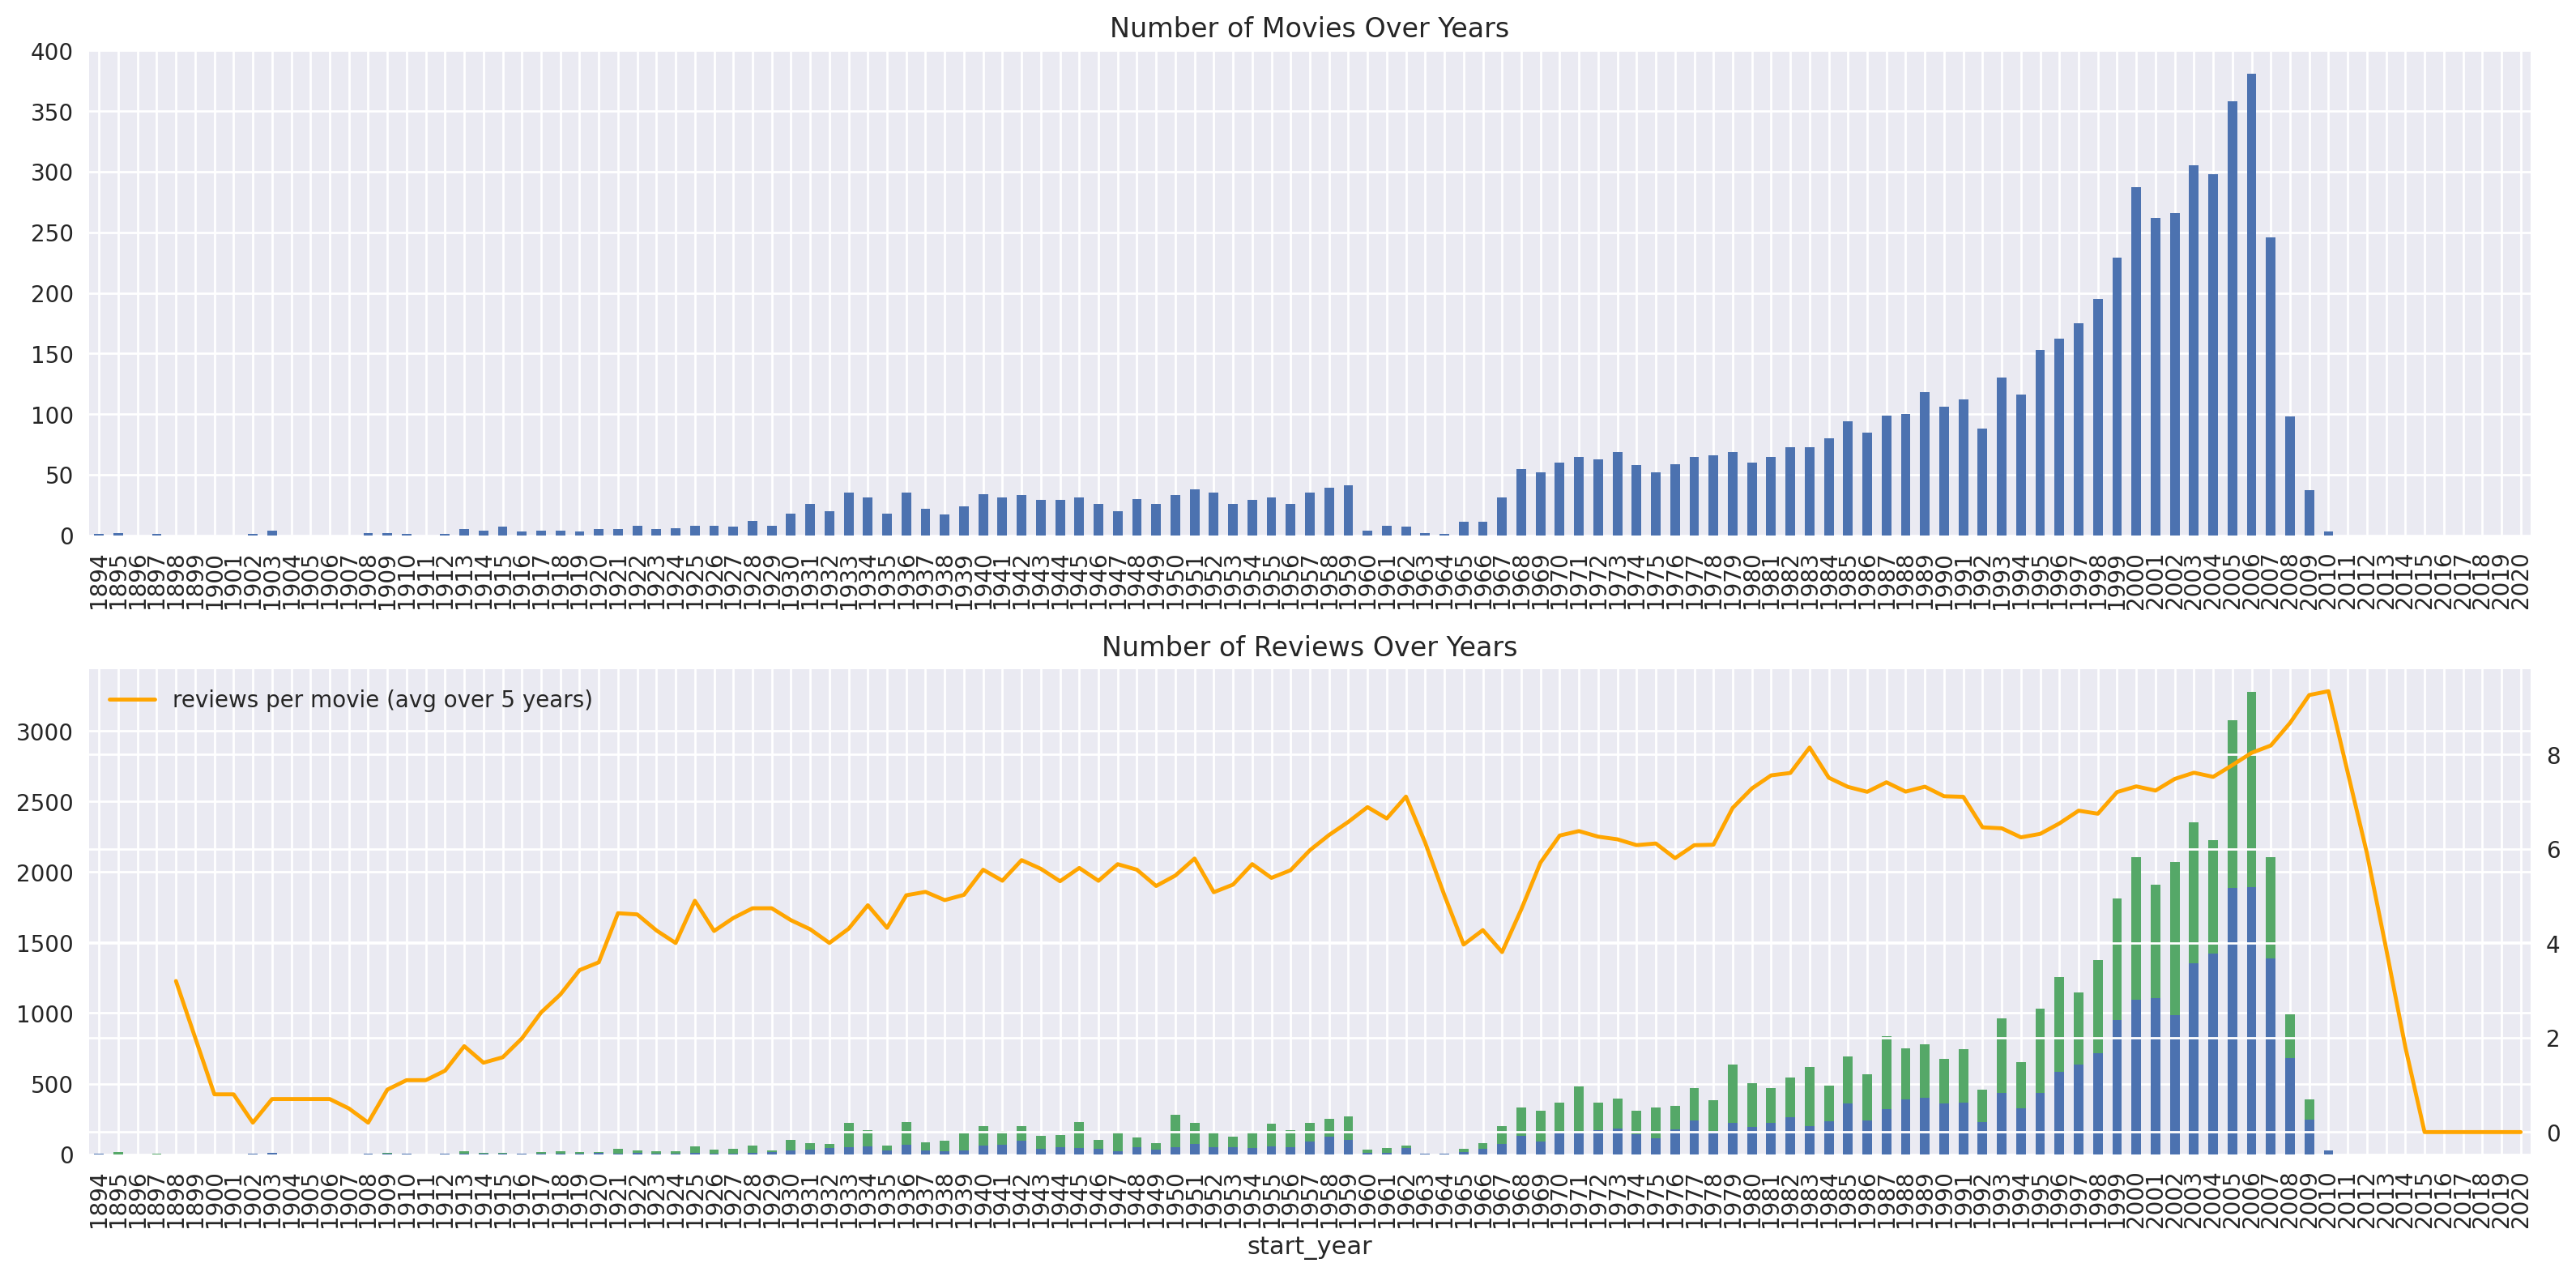

In [63]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

The top chart shows the long term increase of movies released over the years and how there is a large increase after 1990 and peaking in mid-late 2000s.  The bottom graph shows the number of movie reviews also growing rapidly.  It follows a similar trend with the number of movies made over time, showing that the audience is being more engaged through participation and online support.

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

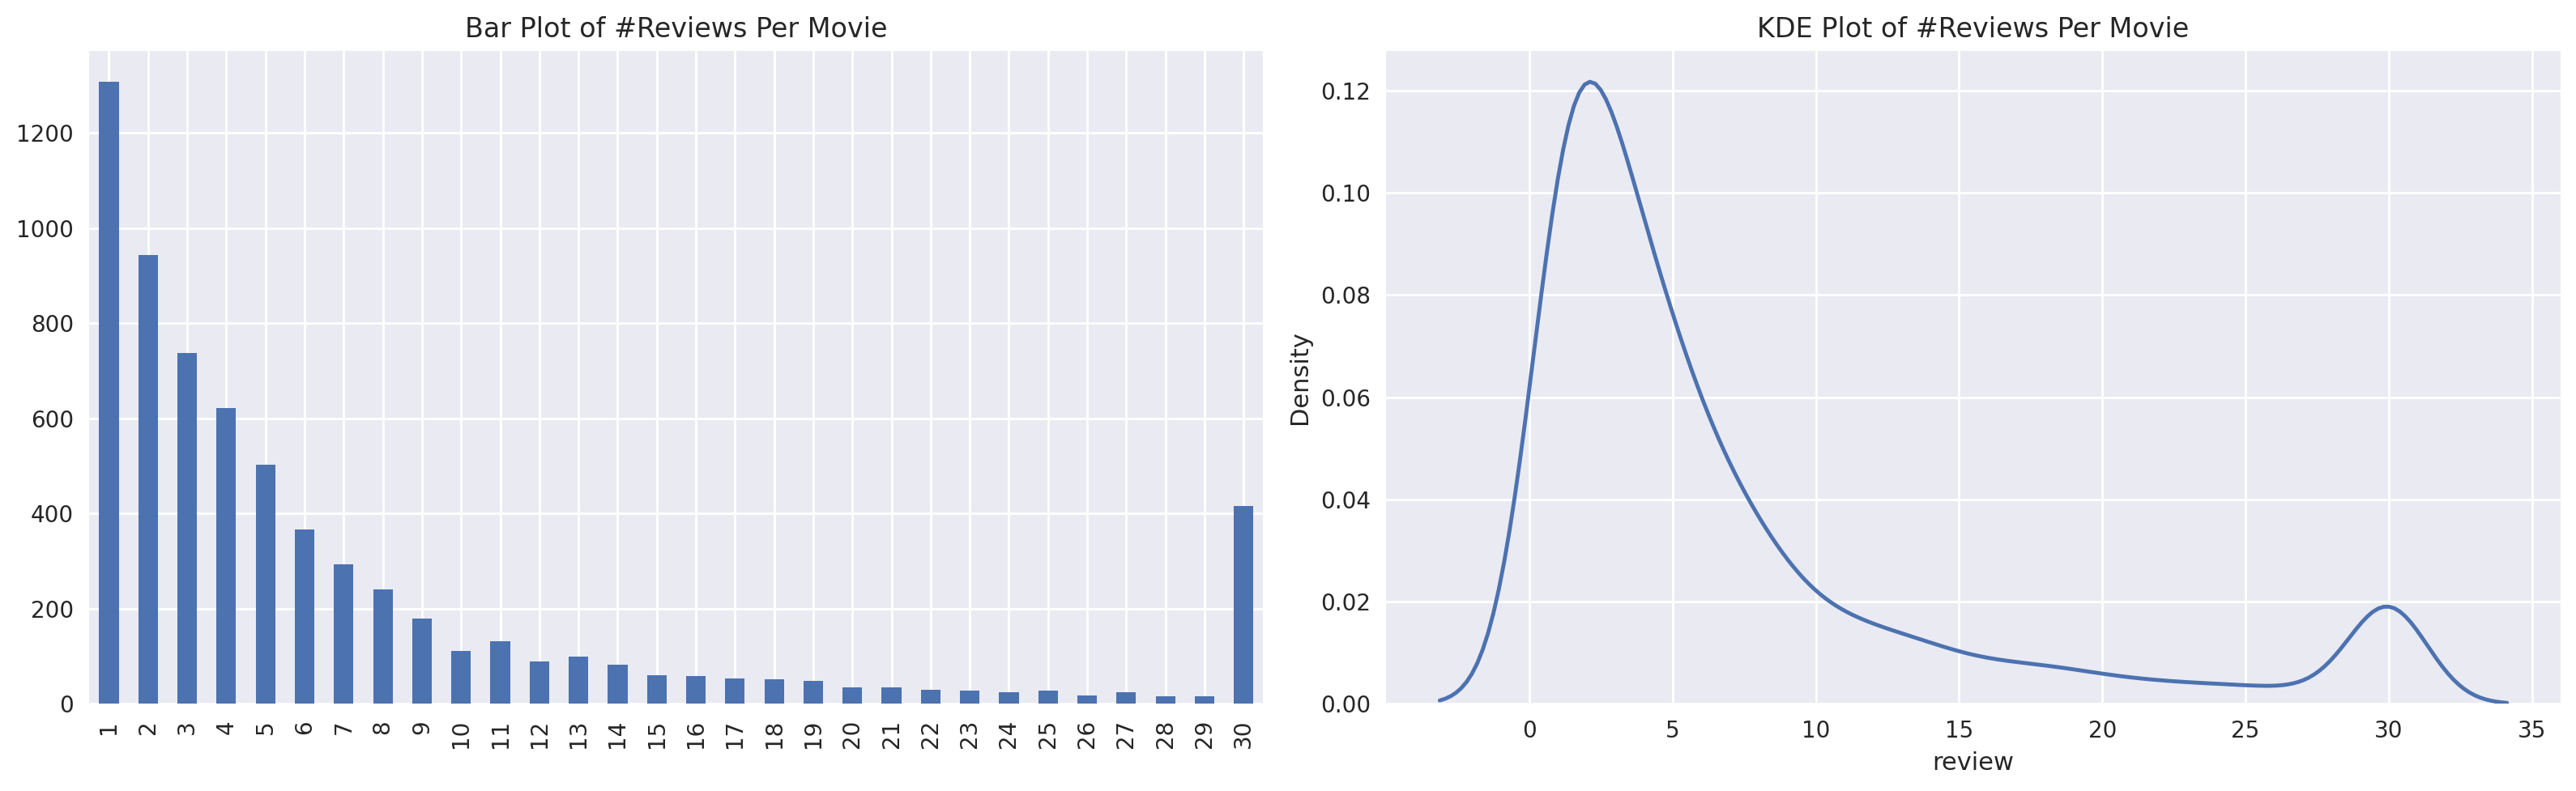

In [64]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

The plot of reviews per movie seems righ-skewed where most movies only receive a small number of reviews.  We do have a few popular movies that have a large amount of reviews.  The KDE plot shows strong peaks with low review counts and a long tail towards high review counts.  This structure suggests that sentiment models must perform well even with limited contextual data per movie, reinforcing the need for robust text representations such as TF-IDF and BERT embeddings.

In [65]:
df_reviews['pos'].value_counts()

0    23715
1    23614
Name: pos, dtype: int64

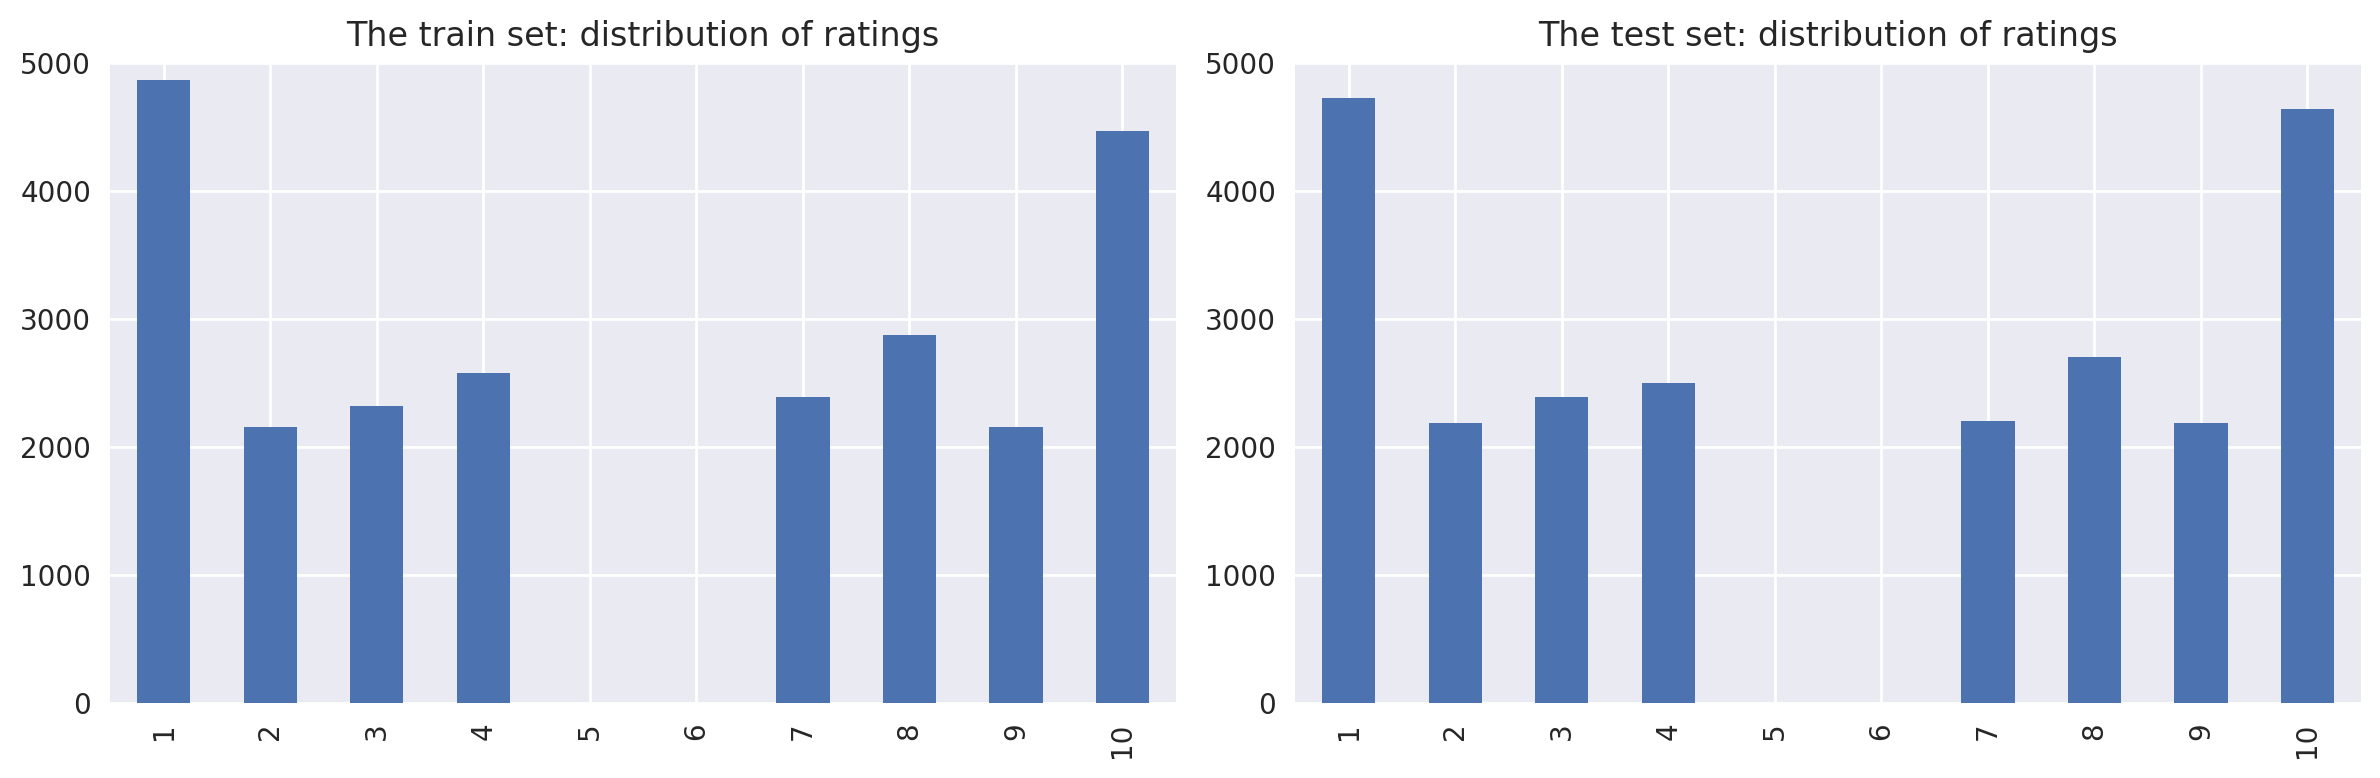

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

The distributions of ratings in the training and test sets are highly similar, indicating that the data split preserves the underlying rating structure. Both sets exhibit a bimodal pattern, with a large concentration of reviews at very low and very high ratings, reflecting strong user sentiment. This consistency ensures that model evaluation is fair and reliable.

Distribution of negative and positive reviews over the years for two parts of the dataset:

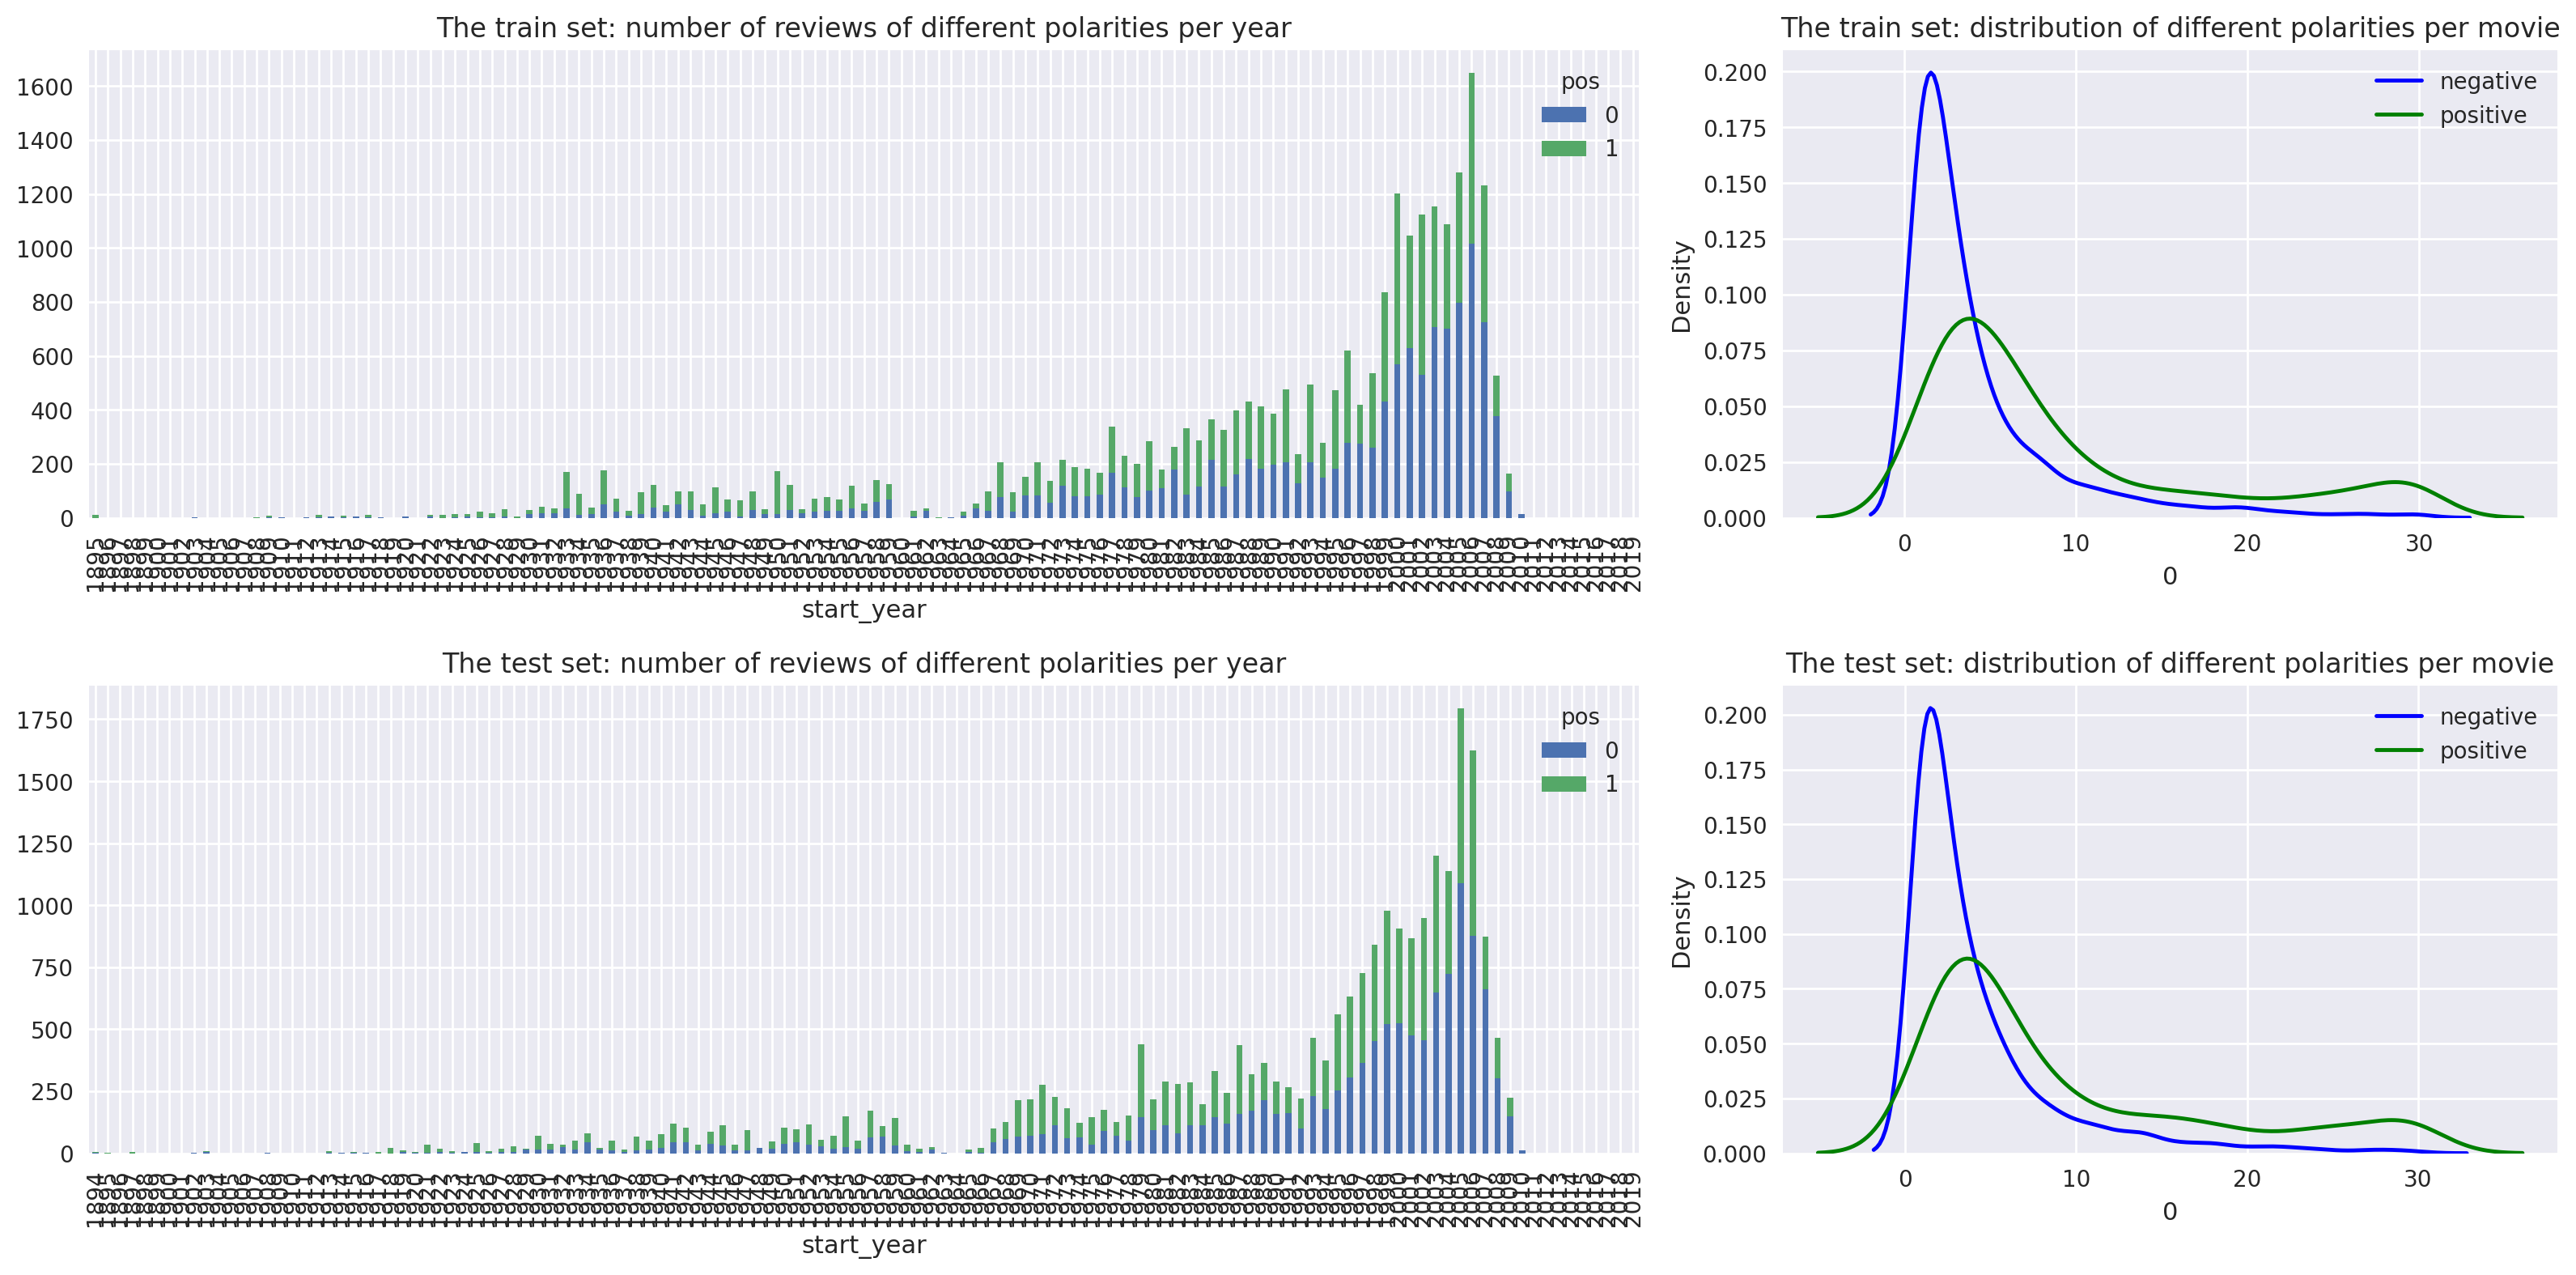

In [67]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

Analysis of sentiment distribution over time shows consistent proportions of positive and negative reviews across both training and test sets. Review volume increases substantially in recent decades, but sentiment balance remains stable, indicating no temporal sentiment drift. Additionally, positive reviews exhibit a heavier right tail in the distribution of reviews per movie, suggesting that popular movies tend to receive more favorable feedback. The near-identical patterns observed in the test set confirm that the data split preserves both temporal and sentiment-related structures, supporting the validity of model evaluation.

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [68]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.  We already did this above.

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [69]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

train_features = df_reviews_train['review_norm']
test_features = df_reviews_test['review_norm']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23533, 18)


## Working with models

### Model 0 - Constant

In [70]:
from sklearn.dummy import DummyClassifier

          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


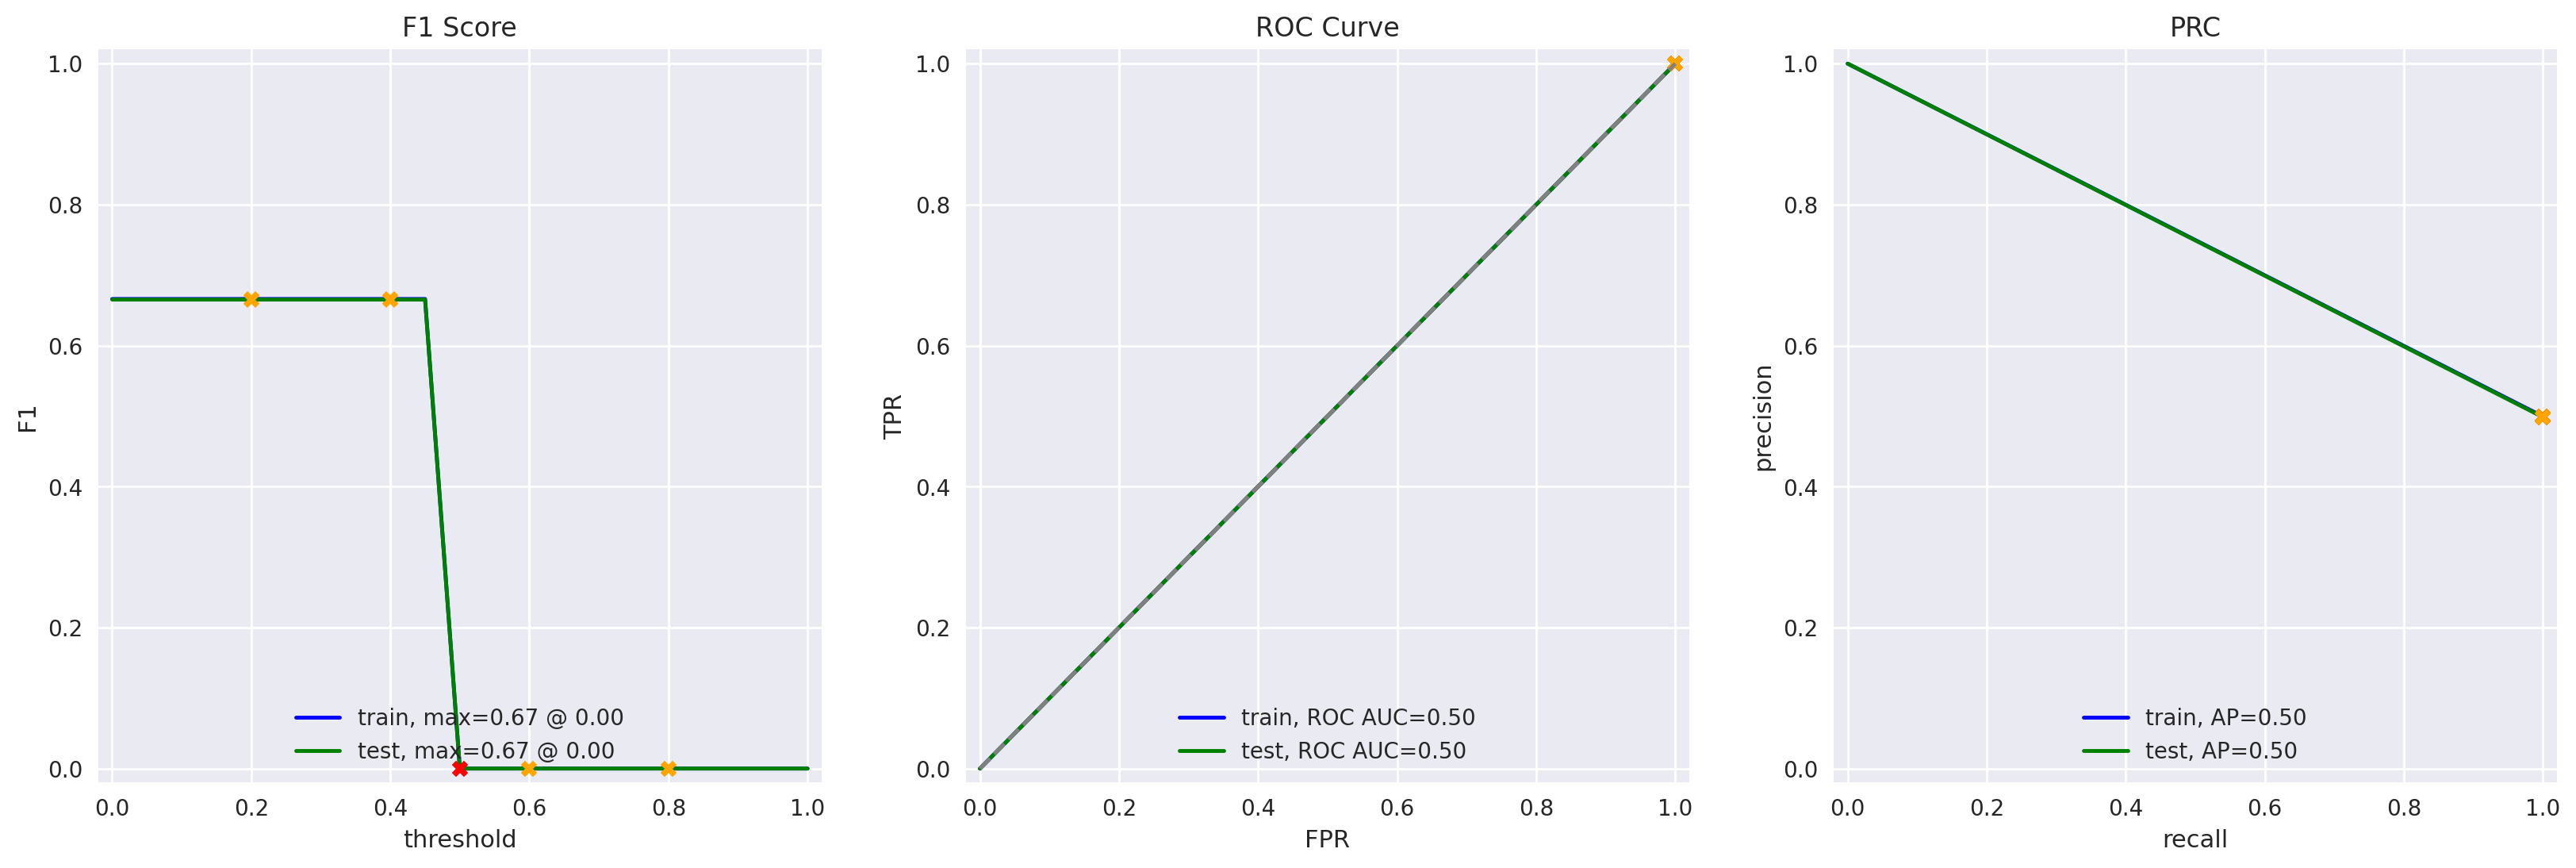

In [71]:
dummy_model = DummyClassifier()
dummy_model.fit(train_features, train_target)

evaluate_model(dummy_model, train_features, train_target, test_features, test_target)

Our base models shows an accuracy score of 50% and a F1 score of 0.5.  THe ROC AUC of 0.5 means it is no better than random guessing.

### Model 1 - NLTK, TF-IDF and LR

This model is Logistic Regression with NLTK preprocessing and TF-IDF vectorization.

In [72]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

In [73]:
# TF-IDF setup
stop_words = set(stopwords.words('english'))
text_transformer_tf_idf = TfidfVectorizer(stop_words='english')

In [74]:
# Function to tokenize and lemmatize text using NLTK
def tokenize_n_lemmatize_using_nltk(text):
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text.lower())
    lemmas = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha()]
    return " ".join(lemmas)

In [75]:
# Apply preprocessing
df_reviews_train['review_lemm_nltk'] = train_features.apply(tokenize_n_lemmatize_using_nltk)
df_reviews_test['review_lemm_nltk'] = test_features.apply(tokenize_n_lemmatize_using_nltk)

In [76]:
# TF-IDF features
train_features_nltk = text_transformer_tf_idf.fit_transform(df_reviews_train['review_lemm_nltk'])
test_features_nltk = text_transformer_tf_idf.transform(df_reviews_test['review_lemm_nltk'])

In [77]:
# Train Logistic Regression
logistic_reg_model = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=12345
)

logistic_reg_model.fit(train_features_nltk, train_target)

LogisticRegression(max_iter=1000, random_state=12345, solver='liblinear')

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


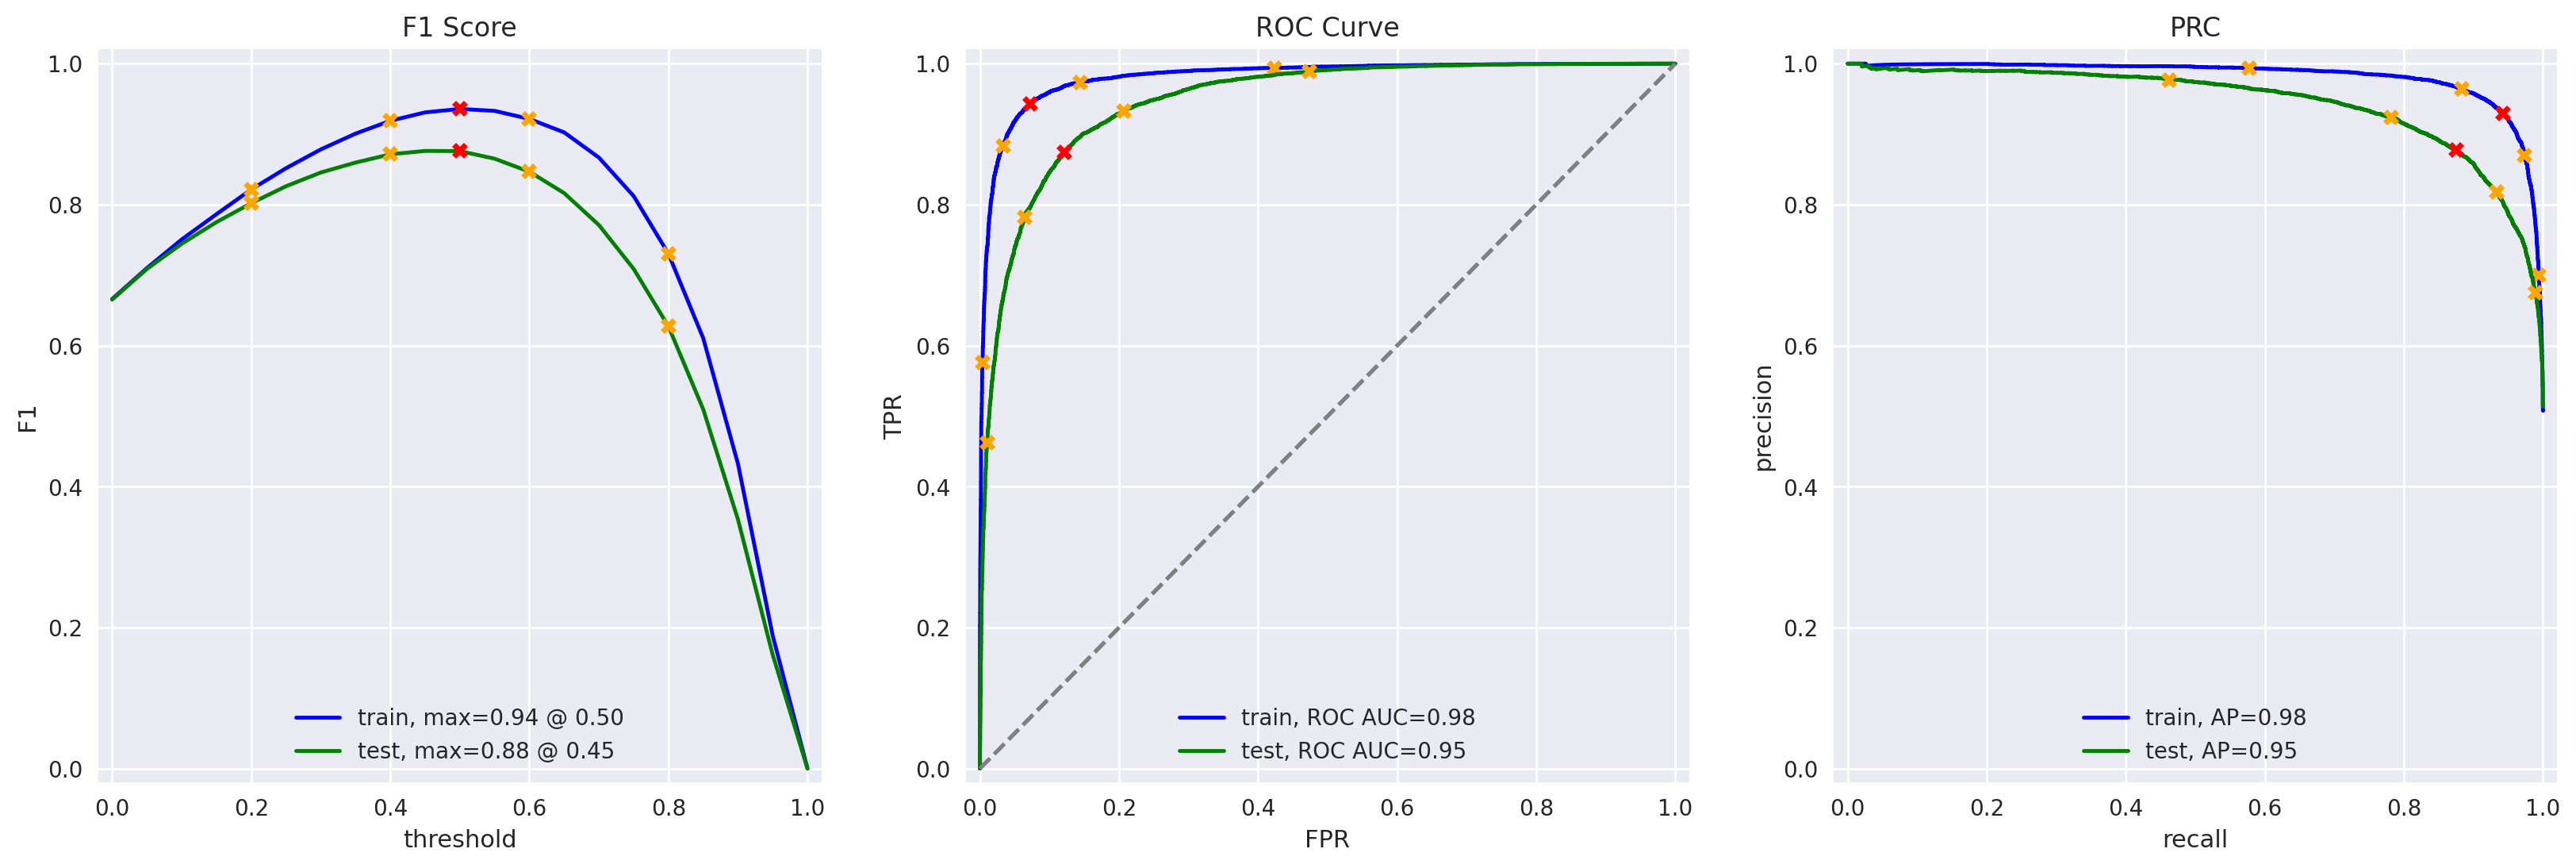

In [78]:
evaluate_model(logistic_reg_model, train_features_nltk, train_target, test_features_nltk, test_target)

- Accuracy: The model achieves 94% training accuracy and 88% test accuracy, showing strong overall performance and good generalization.

- F1 Score: With an F1 score of 0.88 on the test set, the model balances precision and recall effectively.

- APS & ROC AUC: High APS (0.95) and ROC AUC (0.95) on the test data indicate excellent class separation.

- Conclusion: The TF-IDF + Logistic Regression model meets the project’s performance requirements with only minor overfitting

### Model 3 - spaCy, TF-IDF and LR

This model is Logistic Regression with spaCy preprocessing and TF-IDF vectorization.

In [79]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [80]:
def tokenize_n_lemmatize_using_spacy(text):
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if token.is_alpha]  # keep only words
    return " ".join(tokens)

In [81]:
# Apply tokenization and lemmatization to features
df_reviews_train['review_lemm_spacy'] = train_features.apply(tokenize_n_lemmatize_using_spacy)
df_reviews_test['review_lemm_spacy'] = test_features.apply(tokenize_n_lemmatize_using_spacy)

In [82]:
# Calculate TF-IDF features for training and test set
train_features_spacy = text_transformer_tf_idf.fit_transform(df_reviews_train['review_lemm_spacy'])
test_features_spacy = text_transformer_tf_idf.transform(df_reviews_test['review_lemm_spacy'])

In [83]:
# Train Logistic Regression model
logistic_reg_model_2 = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=12345
)

logistic_reg_model_2.fit(train_features_spacy, train_target)

LogisticRegression(max_iter=1000, random_state=12345, solver='liblinear')

          train  test
Accuracy   0.93  0.87
F1         0.93  0.87
APS        0.98  0.94
ROC AUC    0.98  0.95


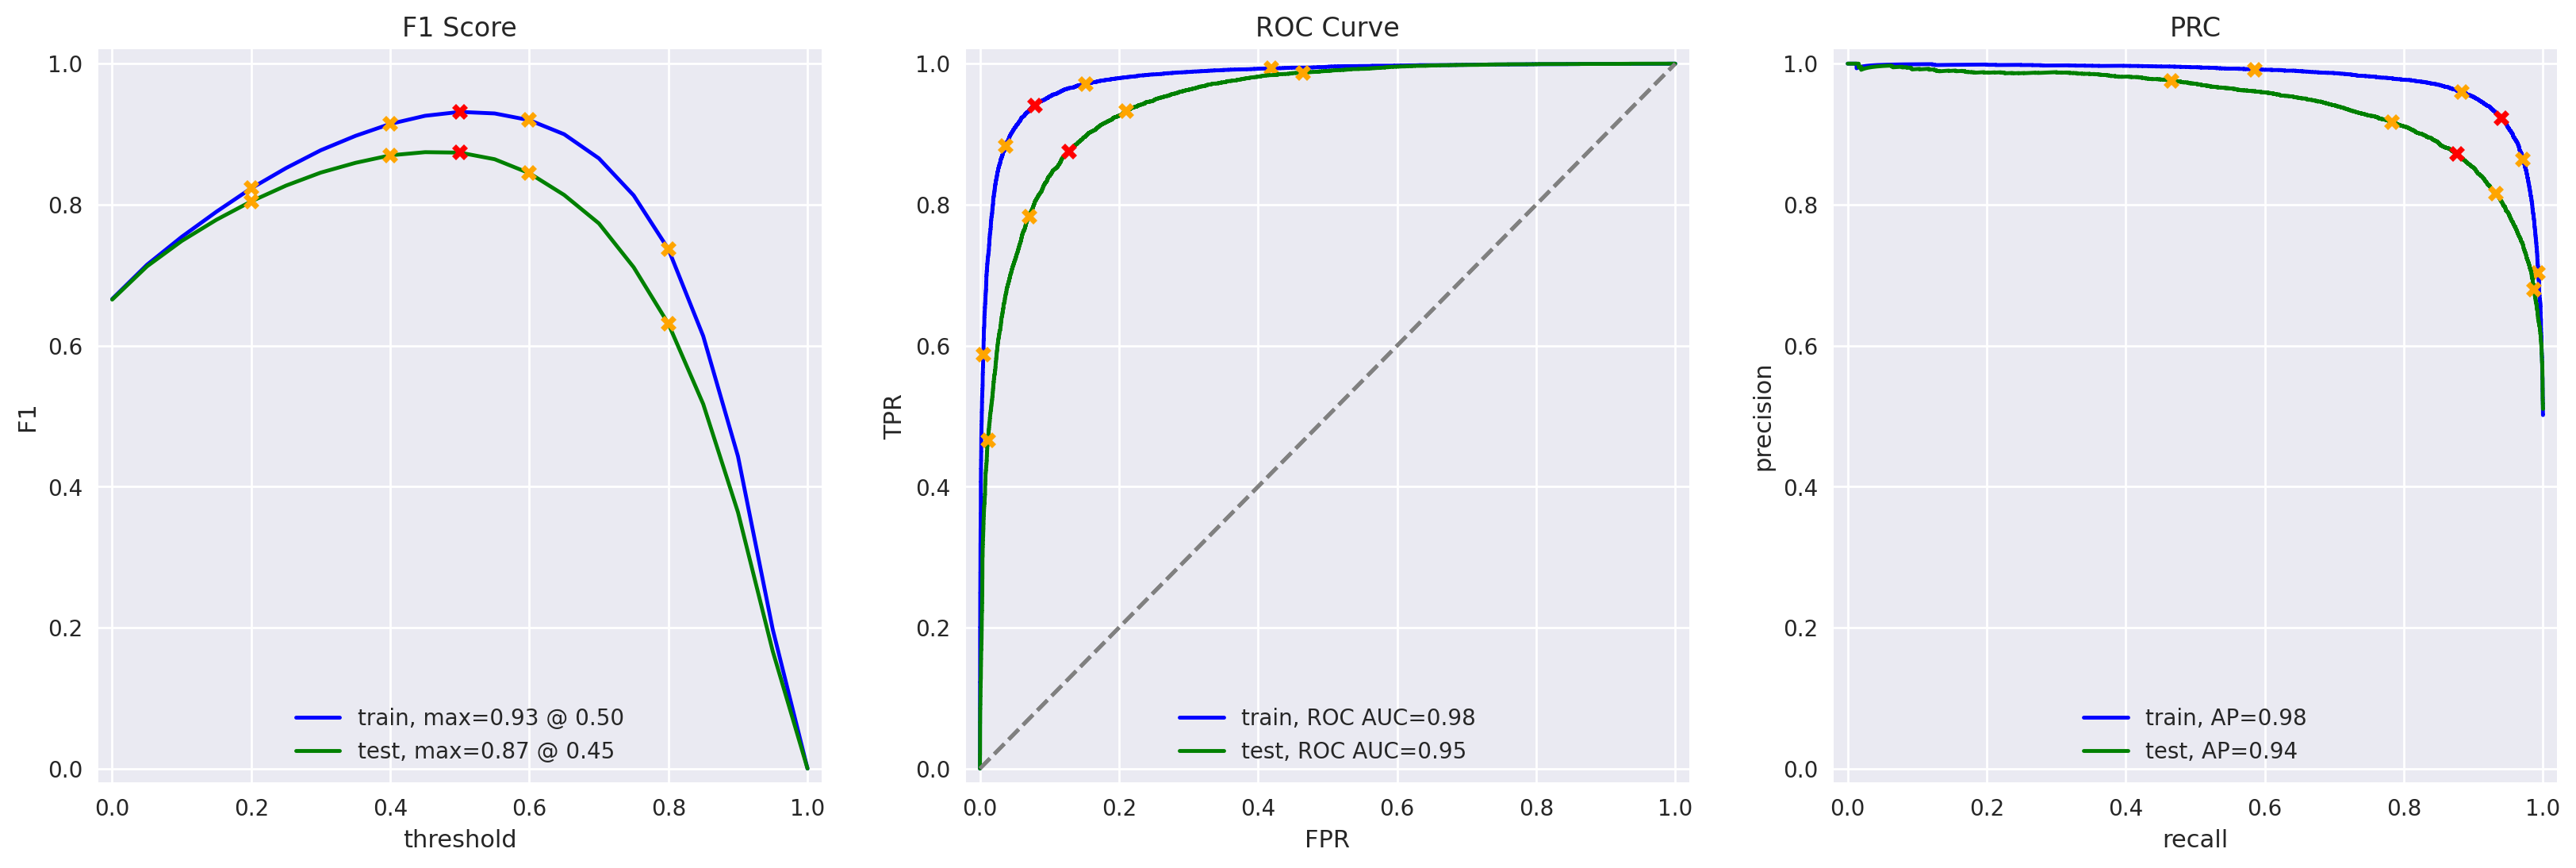

In [84]:
evaluate_model(logistic_reg_model_2, train_features_spacy, train_target, test_features_spacy, test_target)

- Accuracy: The model achieves 93% accuracy on the training set and 87% accuracy on the test set, indicating strong performance with good generalization.

- F1 Score: With a test F1 score of 0.87, the model effectively balances precision and recall for sentiment classification.

- APS & ROC AUC: High APS (0.94) and ROC AUC (0.95) on the test data demonstrate excellent class separability and reliable probability estimates.

- Conclusion: The spaCy + TF-IDF + Logistic Regression model performs comparably to the NLTK-based approach, meeting project requirements with only minor overfitting

### Model 4 - spaCy, TF-IDF and LGBMClassifier

This model is LGBMClassifier with spaCy preprocessing and TF-IDF vectorization.

In [85]:
lgbm_model = LGBMClassifier(random_state=12345)
lgbm_model.fit(train_features_spacy, train_target)

LGBMClassifier(random_state=12345)

          train  test
Accuracy   0.91  0.85
F1         0.91  0.85
APS        0.97  0.93
ROC AUC    0.97  0.93


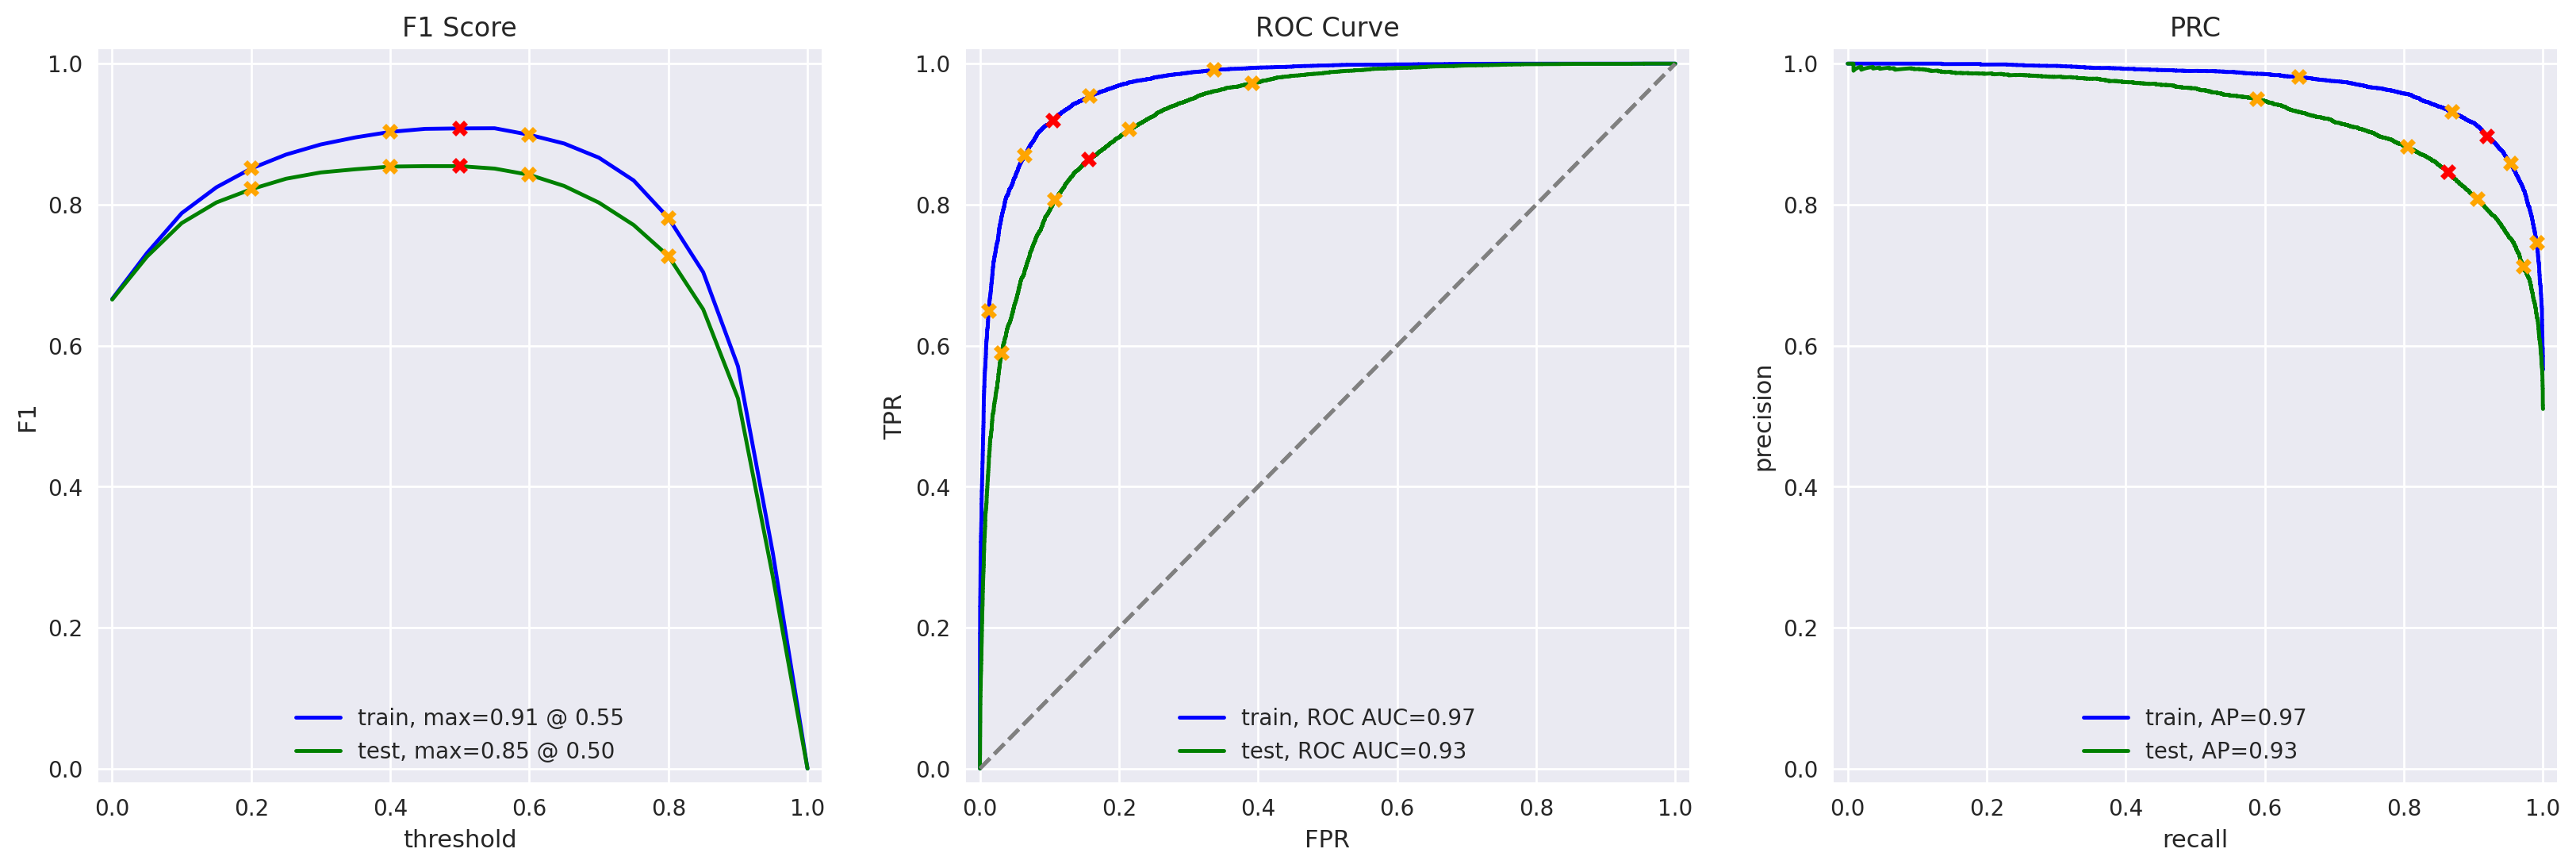

In [86]:
evaluate_model(lgbm_model, train_features_spacy, train_target, test_features_spacy, test_target)

- Accuracy: The model achieves 91% accuracy on the training set and 85% accuracy on the test set, indicating strong performance but slightly weaker generalization compared to Logistic Regression.

- F1 Score: With a test F1 score of 0.85, the model balances precision and recall effectively, though performance is marginally lower than linear models.

- APS & ROC AUC: High APS (0.93) and ROC AUC (0.93) on the test data demonstrate good class separability and reliable probability estimates.

- Conclusion: The spaCy + TF-IDF + LGBMClassifier captures nonlinear patterns but does not outperform simpler Logistic Regression models, while requiring higher computational cost.

###  Model 9 - BERT

In [20]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Due to limitations of the notebook platform and not allowing me to use GPU, I am going to drastically change the function below to reduce load and RAM usage and hopefully we can complete a run without crashing since the kernal crashes quite easily.

In [28]:
def BERT_text_to_embeddings_to_memmap(
    texts,
    out_path="bert_embeddings.dat",
    max_length=32,
    batch_size=2,
    force_device="cpu",
    disable_progress_bar=False
):
    if not isinstance(texts, list):
        texts = texts.tolist()

    device = torch.device(force_device) if force_device is not None else torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    model.to(device)
    model.eval()

    if not disable_progress_bar:
        print(f"Using the {device} device.")

    n = len(texts)
    hidden = model.config.hidden_size  # 768 for bert-base

    # Create memmap on disk (doesn't live fully in RAM)
    out = np.memmap(out_path, dtype="float32", mode="w+", shape=(n, hidden))

    n_batches = math.ceil(n / batch_size)

    with torch.inference_mode():
        for i in tqdm(range(n_batches), disable=disable_progress_bar):
            start = i * batch_size
            end = min((i + 1) * batch_size, n)
            batch_texts = texts[start:end]

            encoded = tokenizer(
                [t.lower() for t in batch_texts],
                add_special_tokens=True,
                max_length=max_length,
                truncation=True,
                padding="max_length",
                return_attention_mask=True,
                return_tensors="pt"
            )

            ids_batch = encoded["input_ids"].to(device)
            attention_mask_batch = encoded["attention_mask"].to(device)

            outputs = model(input_ids=ids_batch, attention_mask=attention_mask_batch)
            batch_cls = outputs.last_hidden_state[:, 0, :].cpu().numpy().astype("float32")

            out[start:end, :] = batch_cls

            # free memory aggressively
            del encoded, ids_batch, attention_mask_batch, outputs, batch_cls
            if i % 50 == 0:
                out.flush()
                gc.collect()

    out.flush()
    return out_path, (n, hidden)

In [25]:
print(len(df_reviews_train))

23796


In [34]:
# Attention! Running BERT for thousands of texts may take long run on CPU, at least several hours
train_features_9 = BERT_text_to_embeddings_to_memmap(df_reviews_train['review_norm'])

Using the cpu device.


 81%|████████  | 9649/11898 [19:09<04:27,  8.40it/s]  

KeyboardInterrupt



In [37]:
import os

def BERT_text_to_embeddings_resume(
    texts,
    out_path="bert_embeddings.dat",   # ✅ matches original default
    max_length=32,                   # ✅ matches original run
    batch_size=2,                    # ✅ matches original run
    force_device="cpu",
    disable_progress_bar=False
):
    if not isinstance(texts, list):
        texts = texts.tolist()

    n = len(texts)
    hidden = model.config.hidden_size  # 768 for bert-base

    # open or create memmap
    mode = "r+" if os.path.exists(out_path) else "w+"
    out = np.memmap(out_path, dtype="float32", mode=mode, shape=(n, hidden))

    # find first unfilled row (assumes unfilled rows are all zeros)
    row_norms = np.linalg.norm(out, axis=1)
    start_idx = int(np.argmax(row_norms == 0.0)) if np.any(row_norms == 0.0) else n

    if start_idx >= n:
        print("Embeddings already complete.")
        return out_path, (n, hidden)

    print(f"Resuming from index {start_idx}/{n} using max_length={max_length}, batch_size={batch_size}")

    device = torch.device(force_device)
    model.to(device)
    model.eval()

    n_batches = math.ceil((n - start_idx) / batch_size)

    with torch.inference_mode():
        for b in tqdm(range(n_batches), disable=disable_progress_bar):
            start = start_idx + b * batch_size
            end = min(start + batch_size, n)
            batch_texts = texts[start:end]

            encoded = tokenizer(
                [t.lower() for t in batch_texts],
                add_special_tokens=True,
                max_length=max_length,
                truncation=True,
                padding="max_length",
                return_attention_mask=True,
                return_tensors="pt"
            )

            ids = encoded["input_ids"].to(device)
            mask = encoded["attention_mask"].to(device)

            outputs = model(input_ids=ids, attention_mask=mask)
            cls = outputs.last_hidden_state[:, 0, :].cpu().numpy().astype("float32")

            out[start:end] = cls

            del encoded, ids, mask, outputs, cls
            if b % 50 == 0:
                out.flush()
                gc.collect()

    out.flush()
    return out_path, (n, hidden)

In [38]:
train_features_9 = BERT_text_to_embeddings_resume(df_reviews_train['review_norm'])

Resuming from index 19298/23796 using max_length=32, batch_size=2


100%|██████████| 2249/2249 [04:18<00:00,  8.70it/s]


In [40]:
# Load the actual embeddings from the memmap file
train_features_9 = np.memmap("bert_embeddings.dat", dtype="float32", mode="r", shape=(23796, 768))

# Now check the shapes
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)

(23796,)
(23796, 768)
(23796,)


In [41]:
# Generate embeddings for the test set (saved to disk, resume-able)
test_path, test_shape = BERT_text_to_embeddings_resume(
    df_reviews_test["review_norm"],   # <-- your test column
    out_path="bert_embeddings_test.dat",
    max_length=32,
    batch_size=2,
    force_device="cpu"
)

print("Saved test embeddings to:", test_path)
print("Test shape:", test_shape)

Resuming from index 0/23533 using max_length=32, batch_size=2


 87%|████████▋ | 10223/11767 [19:28<02:56,  8.75it/s] 

KeyboardInterrupt



In [42]:
test_path, test_shape = BERT_text_to_embeddings_resume(
    df_reviews_test["review_norm"],
    out_path="bert_embeddings_test.dat",
    max_length=32,
    batch_size=2,
    force_device="cpu"
)

Resuming from index 20446/23533 using max_length=32, batch_size=2


100%|██████████| 1544/1544 [02:56<00:00,  8.75it/s]


In [43]:
test_features_9 = np.memmap(
    "bert_embeddings_test.dat",
    dtype="float32",
    mode="r",
    shape=test_shape
)

print(test_features_9.shape)

(23533, 768)


In [44]:
# Train Logistic Regression on BERT features
from sklearn.linear_model import LogisticRegression

bert_lr_model = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=12345
)

bert_lr_model.fit(train_features_9, train_target)

LogisticRegression(max_iter=1000, random_state=12345, solver='liblinear')

          train  test
Accuracy   0.74  0.72
F1         0.74  0.72
APS        0.81  0.79
ROC AUC    0.82  0.79


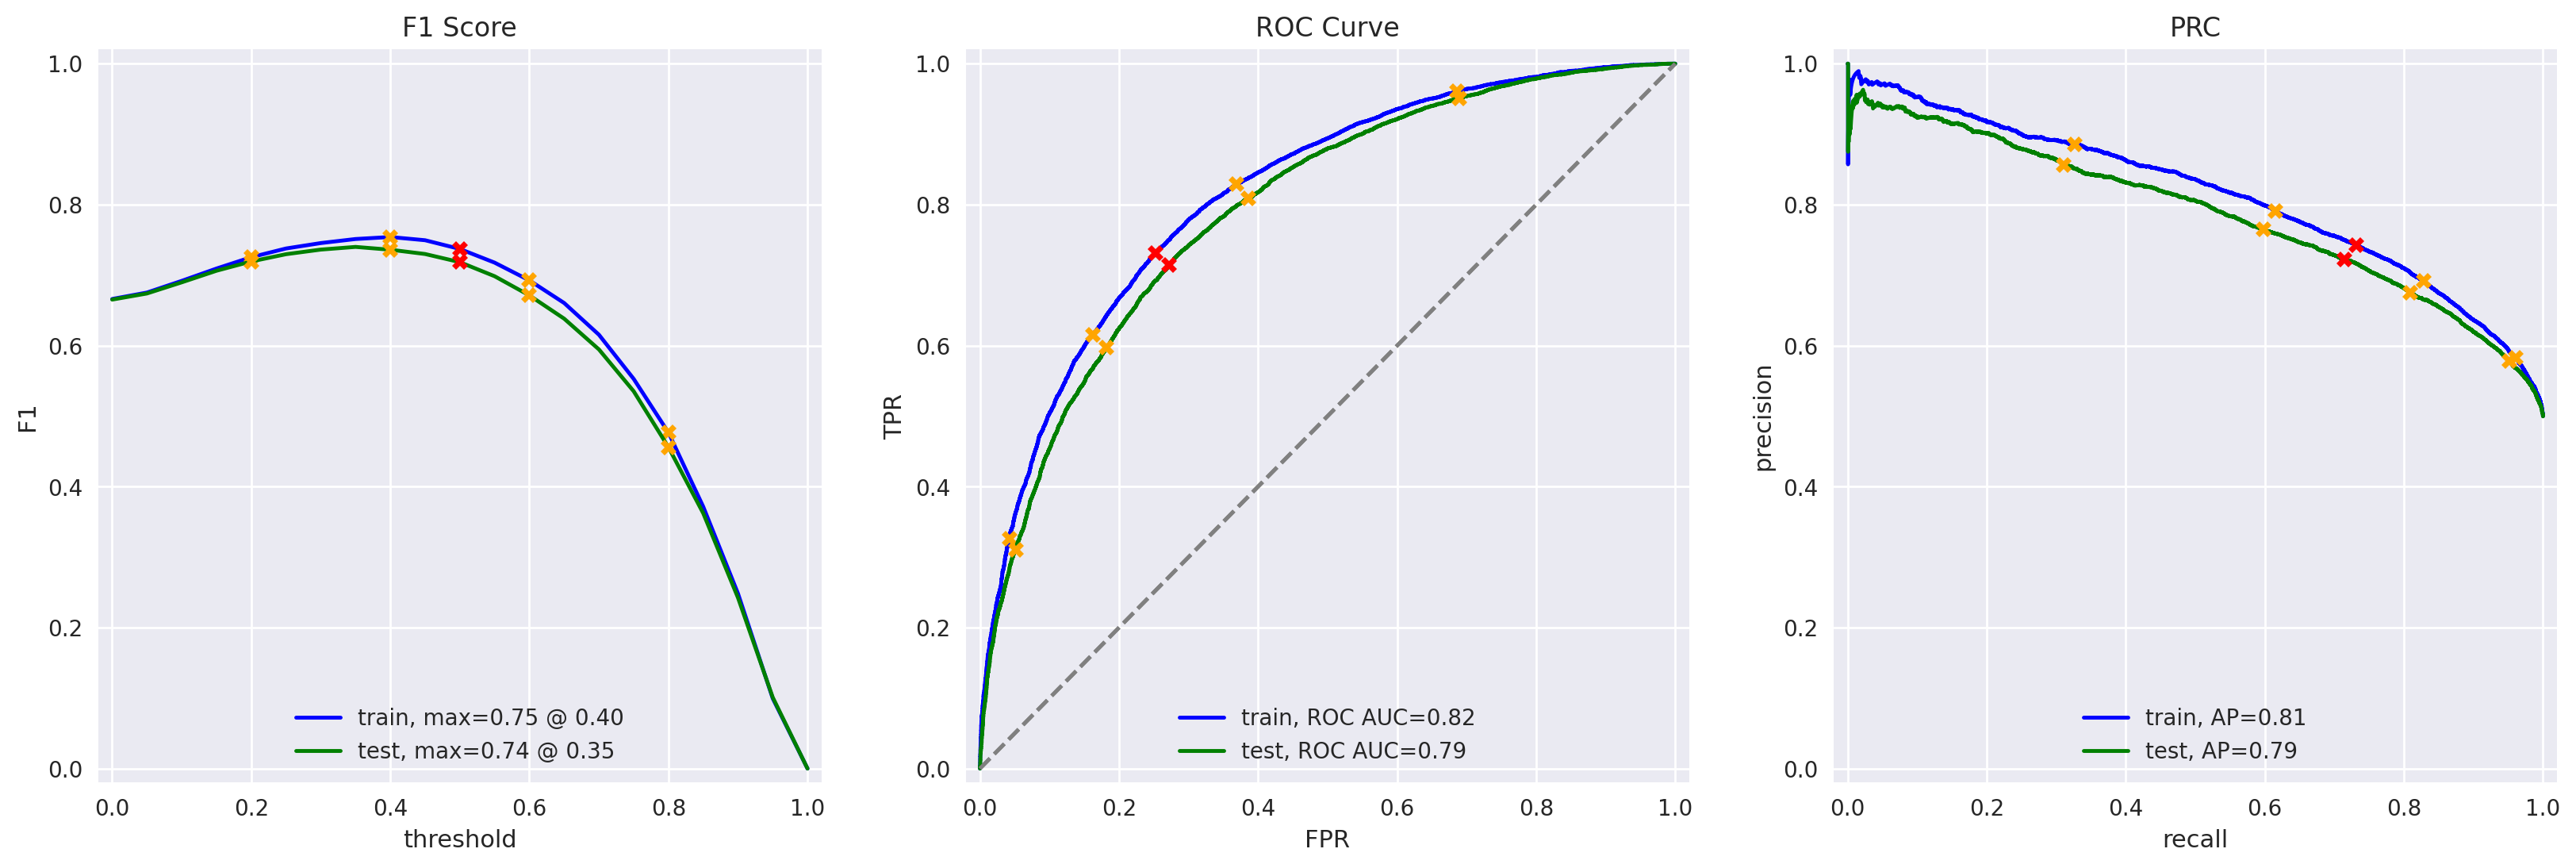

In [45]:
evaluate_model(bert_lr_model, train_features_9, train_target, test_features_9, test_target)

- Accuracy: The model achieves 74% accuracy on the training set and 72% accuracy on the test set, indicating moderate performance but weaker generalization compared to TF-IDF-based models.

- F1 Score: With a test F1 score of 0.72, the model balances precision and recall reasonably well, though it underperforms relative to classical TF-IDF + Logistic Regression approaches.

- APS & ROC AUC: Test APS (0.79) and ROC AUC (0.79) suggest that while BERT embeddings capture semantic information, the resulting feature representations are less effective for linear classification under the given constraints.

- Conclusion: Despite using semantically rich BERT embeddings, this model does not outperform simpler TF-IDF models, likely due to CPU-only inference, reduced sequence length, and the absence of fine-tuning. TF-IDF + Logistic Regression remains the most efficient and effective solution for this task.

## My Reviews

In [47]:
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)  # keep letters, spaces, apostrophes
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [48]:

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)

my_reviews


,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn't expect the reboot to be so good write...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...


### Model 1 - NLTK, TF-IDF and LR

In [99]:
# Re-create the exact setup for Model 1
from sklearn.feature_extraction.text import TfidfVectorizer


# Create a new TF-IDF vectorizer specifically for Model 1

tfidf_model1 = TfidfVectorizer(stop_words='english')

# Fit it on the NLTK-processed training data
train_processed_nltk = df_reviews_train['review_lemm_nltk']
tfidf_model1.fit(train_processed_nltk)

# Now use it for predictions
texts = my_reviews['review_norm']
processed_texts = texts.apply(tokenize_n_lemmatize_using_nltk)
my_reviews_pred_prob = logistic_reg_model.predict_proba(tfidf_model1.transform(processed_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.08:  i did not simply like it not my kind of movie
0.06:  well i was bored and felt asleep in the middle of the movie
0.49:  i was really fascinated with the movie
0.18:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.23:  i didn't expect the reboot to be so good writers really cared about the source material
0.48:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.04:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.90:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Model 3 - spaCy, TF-IDF and LR

In [100]:
texts = my_reviews['review_norm']
processed_texts = texts.apply(tokenize_n_lemmatize_using_spacy)
my_reviews_pred_prob = logistic_reg_model_2.predict_proba(text_transformer_tf_idf.transform(processed_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.19:  i did not simply like it not my kind of movie
0.08:  well i was bored and felt asleep in the middle of the movie
0.50:  i was really fascinated with the movie
0.14:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.23:  i didn't expect the reboot to be so good writers really cared about the source material
0.48:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.03:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.91:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [101]:
texts = my_reviews['review_norm']
processed_texts = texts.apply(tokenize_n_lemmatize_using_spacy)
my_reviews_pred_prob = lgbm_model.predict_proba(text_transformer_tf_idf.transform(processed_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.58:  i did not simply like it not my kind of movie
0.30:  well i was bored and felt asleep in the middle of the movie
0.60:  i was really fascinated with the movie
0.45:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.67:  i didn't expect the reboot to be so good writers really cared about the source material
0.61:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.30:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.80:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


###  Model 9 - BERT

In [102]:
texts = my_reviews['review_norm']

# Generate BERT embeddings for your reviews
my_reviews_path, my_reviews_shape = BERT_text_to_embeddings_resume(
    texts, 
    out_path="my_reviews_bert.dat",
    max_length=32,
    batch_size=2,
    force_device="cpu",
    disable_progress_bar=True
)

# Load the embeddings
my_reviews_features_9 = np.memmap(
    "my_reviews_bert.dat", 
    dtype="float32", 
    mode="r", 
    shape=my_reviews_shape
)

# Make predictions using the correct model
my_reviews_pred_prob = bert_lr_model.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

Embeddings already complete.
0.61:  i did not simply like it not my kind of movie
0.07:  well i was bored and felt asleep in the middle of the movie
0.57:  i was really fascinated with the movie
0.03:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.24:  i didn't expect the reboot to be so good writers really cared about the source material
0.60:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.09:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.77:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


## Conclusions

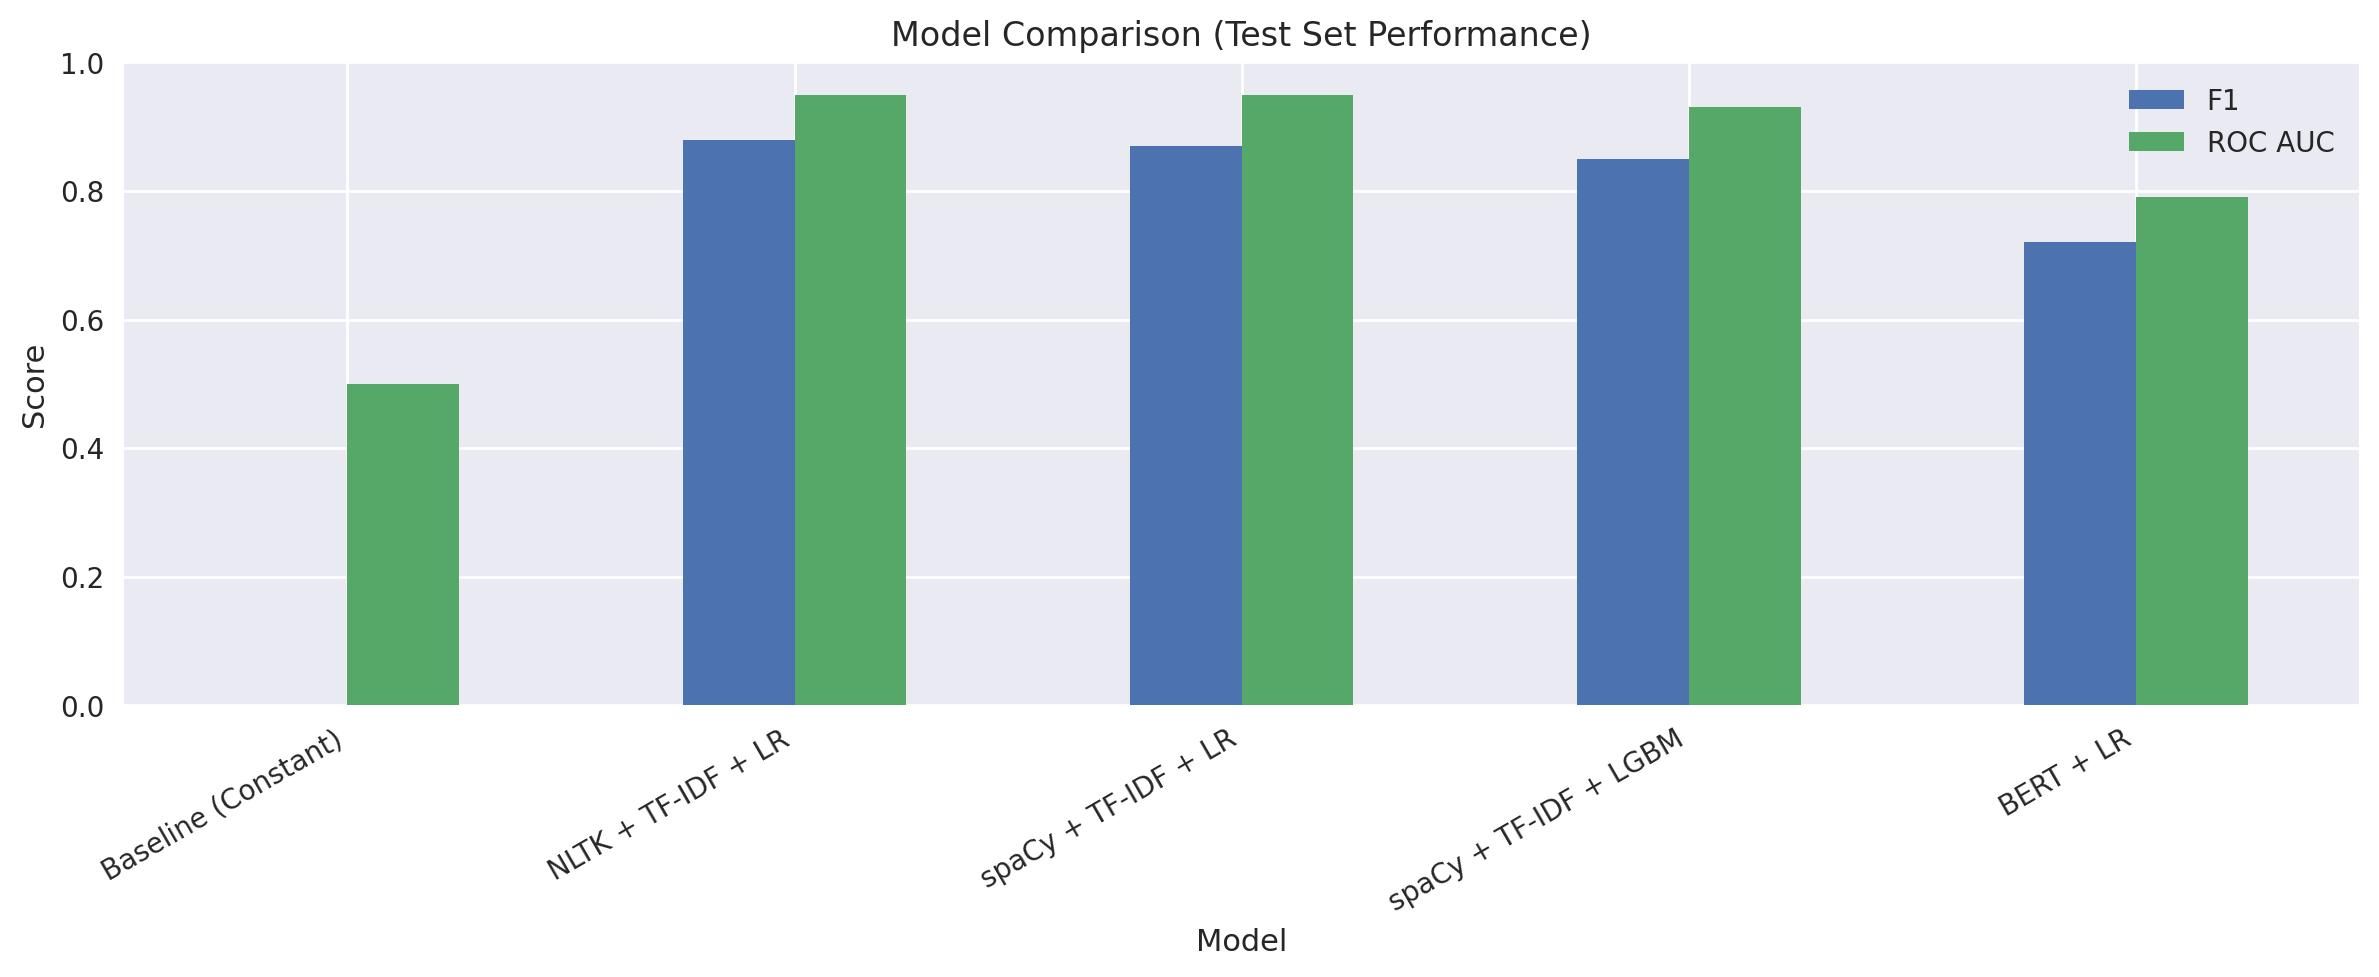

In [103]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline (Constant)",
        "NLTK + TF-IDF + LR",
        "spaCy + TF-IDF + LR",
        "spaCy + TF-IDF + LGBM",
        "BERT + LR"
    ],
    "Accuracy": [0.50, 0.88, 0.87, 0.85, 0.72],
    "F1":       [0.00, 0.88, 0.87, 0.85, 0.72],
    "ROC AUC":  [0.50, 0.95, 0.95, 0.93, 0.79],
    "APS":      [0.50, 0.95, 0.94, 0.93, 0.79]
})

model_comparison.set_index("Model")[["F1", "ROC AUC"]].plot(
    kind="bar",
    figsize=(12, 5),
    ylim=(0, 1),
    title="Model Comparison (Test Set Performance)"
)

plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

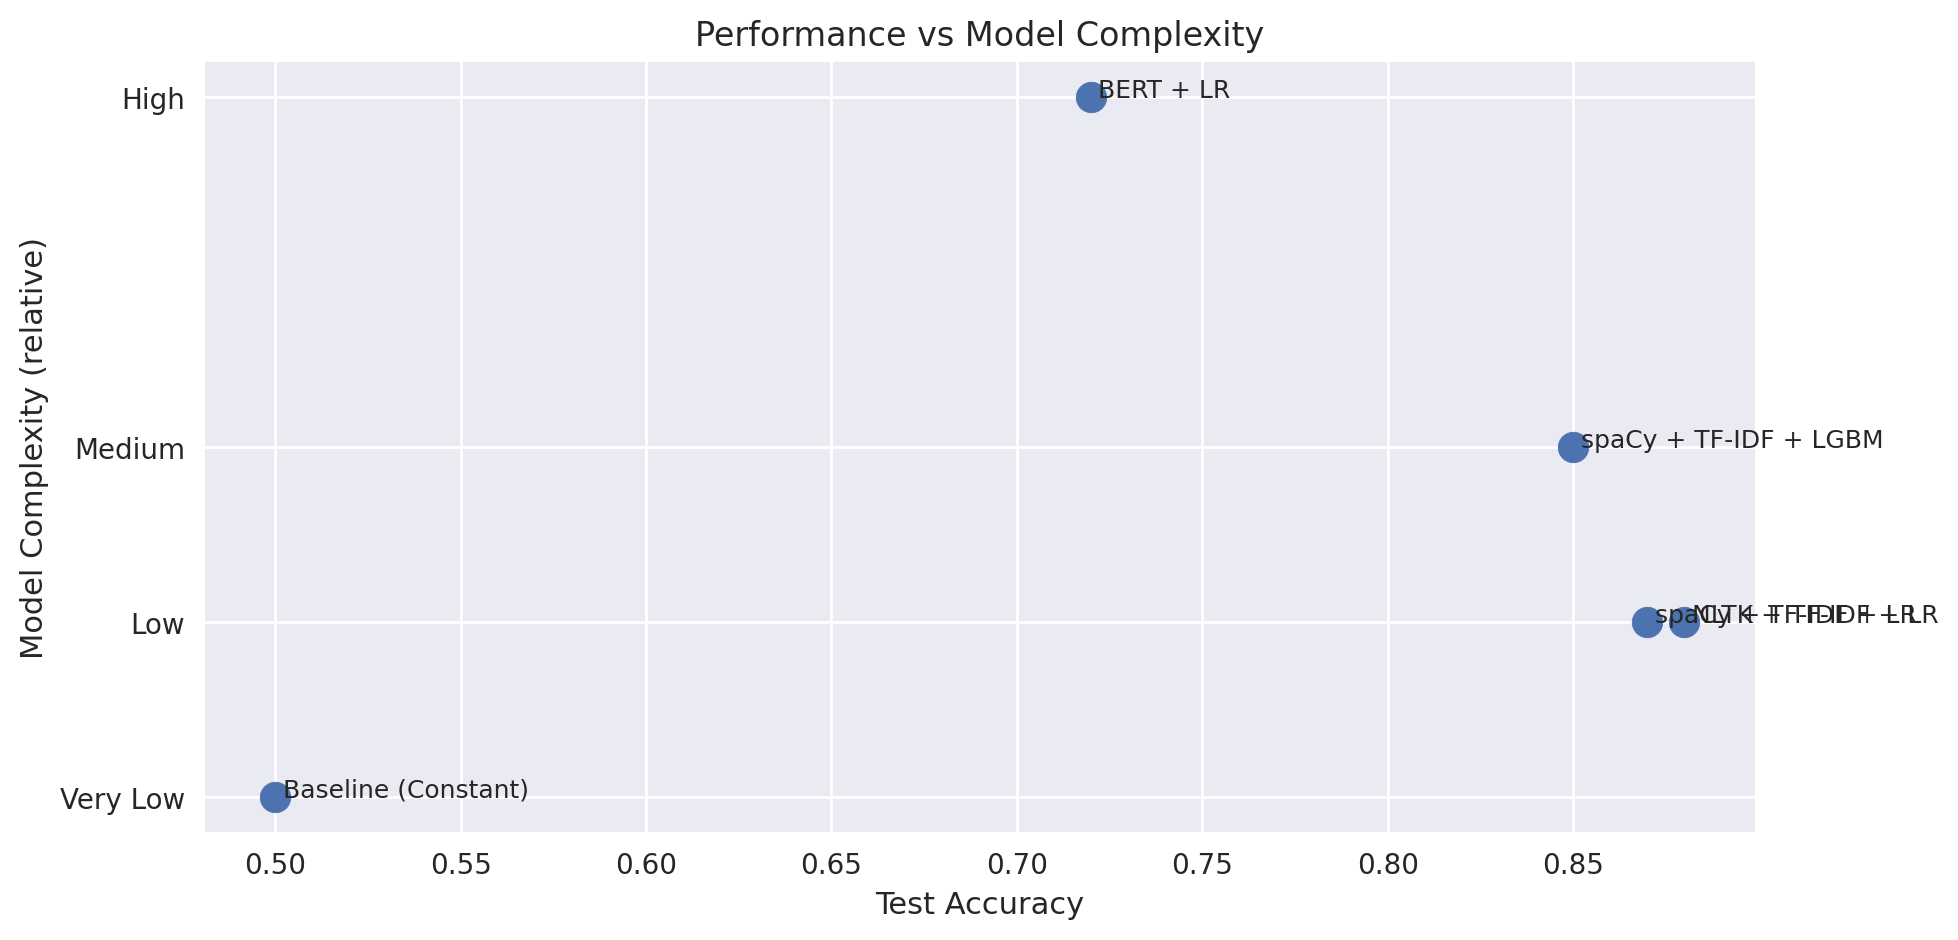

In [105]:
plt.figure(figsize=(10, 5))
plt.scatter(
    model_comparison["Accuracy"],
    [1, 2, 2, 3, 5],  # rough complexity scale
    s=120
)
for i, name in enumerate(model_comparison["Model"]):
    plt.text(
        model_comparison["Accuracy"][i] + 0.002,
        [1, 2, 2, 3, 5][i],
        name,
        fontsize=9
    )
plt.xlabel("Test Accuracy")
plt.ylabel("Model Complexity (relative)")
plt.title("Performance vs Model Complexity")
plt.yticks([1, 2, 3, 5], ["Very Low", "Low", "Medium", "High"])  # ✅ Fixed: 4 positions, 4 labels
plt.grid(True)
plt.show()

## Conclusions

The goal of this project was to develop a sentiment classification model for movie reviews with a minimum F1 score of **0.85**. Multiple models were trained and evaluated using different preprocessing techniques and text representations.

### Key Findings

- **TF-IDF + Logistic Regression (NLTK preprocessing)** achieved the best performance, with a **test F1 score of ~0.88** and **accuracy of ~0.88**, while remaining fast and stable.
- A similar model using **spaCy preprocessing** produced nearly identical results (**F1 ≈ 0.87**, **accuracy ≈ 0.87**), indicating that TF-IDF features were more influential than the choice of NLP library.
- **LightGBM with TF-IDF** did not outperform Logistic Regression and required additional computational cost, achieving a lower **test F1 score (~0.85)**.
- **BERT embeddings + Logistic Regression** achieved only **moderate performance** (**test F1 ≈ 0.72**, **accuracy ≈ 0.72**) despite significantly higher computational requirements.

---

### Final Decision

- The **TF-IDF + Logistic Regression model with NLTK preprocessing** was selected as the final solution.
- **Preprocessing steps included** text normalization (lowercasing, removal of non-alphabetic characters except apostrophes), tokenization, lemmatization, and TF-IDF vectorization.
- This model provided the **best balance of performance and efficiency**, exceeding the project’s F1 requirement while training and predicting quickly on CPU.

---

### Notes on BERT Performance

- Although BERT embeddings are semantically rich, their effectiveness in this project was **limited by infrastructure constraints**.
- BERT inference was performed on **CPU only**, required reduced sequence length, and did not include fine-tuning, all of which negatively impacted performance.
- As a result, BERT did not outperform simpler TF-IDF-based models, despite requiring significantly more time and memory.
- With GPU support and fine-tuning, BERT could potentially achieve stronger results; however, under the current constraints, it was not the most practical choice.

---

**Overall conclusion:**  
This project demonstrates that **well-preprocessed TF-IDF models combined with Logistic Regression can outperform more complex deep learning approaches** when computational resources are limited, making them a strong and reliable choice for sentiment analysis tasks.